In [56]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import torchvision 
from torchvision import transforms, datasets
import torch.optim as optim
import time
from tqdm import tqdm
import os
from torch.cuda.amp import autocast, GradScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm  # 进度条
import time

# 设置matplotlib中文字体（如果需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# 设置随机种子保证可重复性
torch.manual_seed(42)
np.random.seed(42)

1. 创建$Dense$的最小的那个层，就是$Bn+CONV+RELU$

In [57]:
def dense_layer(in_channels , out_channels , bn_size = 4 , drop_rate = 0.5):
    return (
        nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace = True),
            nn.Conv2d(
                in_channels = in_channels , 
                out_channels = bn_size * out_channels, 
                kernel_size = 1 , 
                padding = 0 , 
                stride = 1
                ),
            nn.BatchNorm2d(bn_size * out_channels),
            nn.ReLU(inplace = True),
            nn.Conv2d(
                in_channels = bn_size * out_channels , 
                out_channels = out_channels , 
                kernel_size = 3 , 
                padding = 1 , 
                stride = 1
                ),
            nn.Dropout(p = drop_rate) if drop_rate > 0 else nn.Identity()
        )
    )

# x = torch.randn(4 , 3 , 32 , 32)
# layer = dense_layer(3 , 32)
# print(layer(x).shape)

2. 创建$DenseNet$的中间过度层用来降低空间维度和通道数的，减半操作

In [58]:
def dense_transition(in_channels , out_channels):
    return (
        nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace = True),
            nn.Conv2d(
                in_channels=in_channels , 
                out_channels=out_channels,
                kernel_size=1,
                padding = 0 ,
                stride=1
            ),
            nn.AvgPool2d(kernel_size=2 , stride=2)
        )
    )

# x = torch.randn(4 , 64 , 32 , 32)
# layer = dense_transition(64 , 32)
# print(layer(x).shape)

3. 创建$Dense$的基本单元

In [59]:
class DenseBlock(nn.Module):
    def __init__(self , num_layers , in_channels ,  growth_rate = 32):
        super(DenseBlock , self).__init__()
        self.num_layers = num_layers
        layers = []
        for i in range (self.num_layers):
            layer = dense_layer(
                in_channels= in_channels +i * growth_rate,
                out_channels= growth_rate
            )
            layers.append(layer)
        self.layers = nn.Sequential(*layers)

    def forward(self , x):
        for layer in self.layers:
            y = layer(x)
            x = torch.cat([x , y] , dim =1)
        return x

# x = torch.randn(4 , 2 , 32 , 32)
# layer = DenseBlock(num_layers=1 , in_channels=2 , growth_rate=32)
# layer(x).size()
        

4. $DenseNet$网络结构

In [60]:
class DenseNet(nn.Module):
    def __init__(self , growth_rate = 32 , num_classes = 10 , in_channels = 3 , init_features = 64):
        super(DenseNet , self).__init__()

        # 初始卷积层
        self.init_conv = nn.Sequential(
            nn.Conv2d(
                in_channels= in_channels ,
                out_channels = init_features ,
                kernel_size = 7 ,
                stride = 2 ,
                padding = 3
                ),
            nn.BatchNorm2d(init_features),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(kernel_size=3 , stride=2 , padding=1),
            )
        
        # 密集块和过度层
        num_channels = init_features
        self.block1 = DenseBlock(num_layers = 6 , in_channels = num_channels , growth_rate = growth_rate)
        num_channels = num_channels + 6 * growth_rate
        self.trans1 = dense_transition(in_channels = num_channels , out_channels = num_channels // 2)
        num_channels = num_channels // 2

        self.block2 = DenseBlock(num_layers = 12 , in_channels = num_channels , growth_rate = growth_rate)
        num_channels = num_channels + 12 * growth_rate
        self.trans2 = dense_transition(in_channels = num_channels , out_channels = num_channels // 2)
        num_channels = num_channels // 2

        self.block3 = DenseBlock(num_layers = 24 , in_channels = num_channels , growth_rate = growth_rate)
        num_channels = num_channels + 24 * growth_rate
        self.trans3 = dense_transition(in_channels = num_channels , out_channels = num_channels // 2)
        num_channels = num_channels // 2

        self.block4 = DenseBlock(num_layers = 16 , in_channels = num_channels , growth_rate = growth_rate)
        num_channels = num_channels + 16 * growth_rate

        # 全局平均池化和分类层
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1 , 1))
        self.classifier = nn.Linear(num_channels , num_classes)

    def forward(self , x):
        x = self.init_conv(x)
        x = self.block1(x)
        x = self.trans1(x)
        x = self.block2(x)
        x = self.trans2(x)
        x = self.block3(x)
        x = self.trans3(x)
        x = self.block4(x)
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [61]:
#测试代码
x = torch.randn(4 , 3 , 224, 224)
# x = torch.flatten(x , start_dim=1)
# x.size()
models = DenseNet()
models(x).shape

torch.Size([4, 10])

使用CIFAR-10来看看效果吧

In [62]:
def simple_train_model(model, train_loader, val_loader, num_epochs=10, lr=0.001):
    """简化的训练函数，只显示损失和准确率曲线"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 记录训练过程
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    # 创建图形
    plt.ion()  # 开启交互模式
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    for epoch in range(num_epochs):
        # 训练阶段
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for batch_idx, (inputs, targets) in enumerate(train_bar):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += targets.size(0)
            correct_train += predicted.eq(targets).sum().item()
            
            train_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct_train/total_train:.2f}%'
            })
        
        avg_train_loss = train_loss / len(train_loader)
        train_accuracy = 100. * correct_train / total_train
        
        # 验证阶段
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
            for inputs, targets in val_bar:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total_val += targets.size(0)
                correct_val += predicted.eq(targets).sum().item()
                
                val_bar.set_postfix({
                    'Loss': f'{loss.item():.4f}',
                    'Acc': f'{100.*correct_val/total_val:.2f}%'
                })
        
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100. * correct_val / total_val
        
        # 记录结果
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
        
        # 实时更新图表
        ax1.clear()
        ax1.plot(train_losses, 'b-', label='Train Loss', linewidth=2)
        ax1.plot(val_losses, 'r-', label='Val Loss', linewidth=2)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title(f'Loss Curves (Epoch {epoch+1})')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2.clear()
        ax2.plot(train_accs, 'b-', label='Train Acc', linewidth=2)
        ax2.plot(val_accs, 'r-', label='Val Acc', linewidth=2)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy (%)')
        ax2.set_title(f'Accuracy Curves (Epoch {epoch+1})')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim([0, 100])
        
        plt.tight_layout()
        plt.draw()
        plt.pause(0.1)
        
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        print(f'  训练损失: {avg_train_loss:.4f}, 训练准确率: {train_accuracy:.2f}%')
        print(f'  验证损失: {avg_val_loss:.4f}, 验证准确率: {val_accuracy:.2f}%')
        print('-' * 50)
    
    # 训练结束
    plt.savefig('training_curves.png')
    plt.ioff()
    plt.show()
    
    return model

Files already downloaded and verified
Files already downloaded and verified


Epoch 1/20 [Val]: 100%|██████████| 157/157 [00:09<00:00, 15.80it/s, Loss=1.3816, Acc=47.37%]


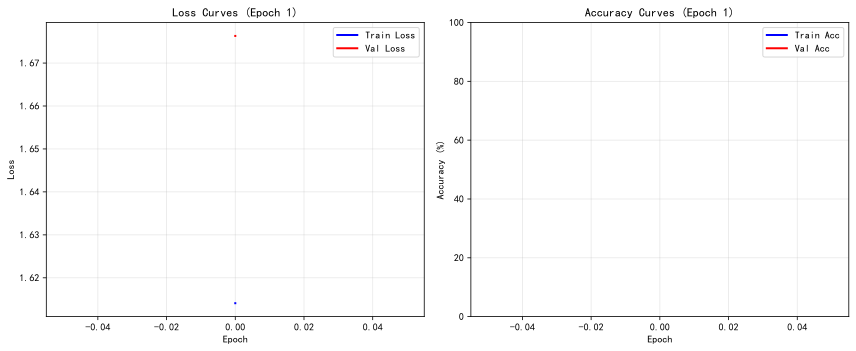


Epoch 1/20:
  训练损失: 1.6141, 训练准确率: 40.19%
  验证损失: 1.6763, 验证准确率: 47.37%
--------------------------------------------------


Epoch 2/20 [Val]: 100%|██████████| 157/157 [00:11<00:00, 14.21it/s, Loss=1.1326, Acc=55.26%]


<Figure size 640x480 with 0 Axes>


Epoch 2/20:
  训练损失: 1.2930, 训练准确率: 53.15%
  验证损失: 1.3358, 验证准确率: 55.26%
--------------------------------------------------


Epoch 3/20 [Val]: 100%|██████████| 157/157 [00:11<00:00, 13.66it/s, Loss=1.4974, Acc=62.72%]


...


Epoch 19/20:
  训练损失: 0.5493, 训练准确率: 81.01%
  验证损失: 0.7367, 验证准确率: 78.56%
--------------------------------------------------


Epoch 20/20 [Val]: 100%|██████████| 157/157 [00:09<00:00, 16.92it/s, Loss=0.8001, Acc=78.93%]


<Figure size 640x480 with 0 Axes>


Epoch 20/20:
  训练损失: 0.5356, 训练准确率: 81.10%
  验证损失: 0.7217, 验证准确率: 78.93%
--------------------------------------------------


<Figure size 640x480 with 0 Axes>

In [63]:
# 1. 准备数据
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.CIFAR10(
    root='E:\\mastercode\\data', 
    train=True, 
    download=True, 
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root='E:\\mastercode\\data',
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# 2. 创建模型
model = DenseNet(num_classes=10, in_channels=3, init_features=64)

# 3. 开始训练（使用修复后的版本）
# model = train_model(model, train_loader, test_loader, num_epochs=20)

# 或者使用简化版（只显示曲线）
model = simple_train_model(model, train_loader, test_loader, num_epochs=20)